In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("/content/creditcard.csv")

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split (important: split BEFORE SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


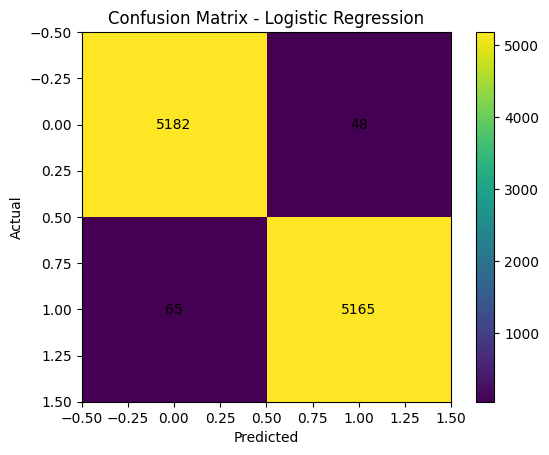

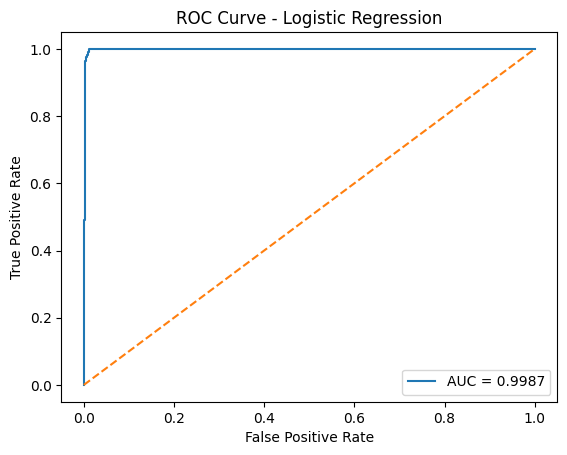

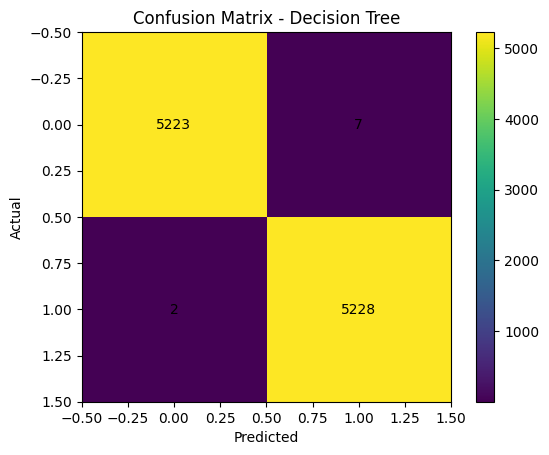

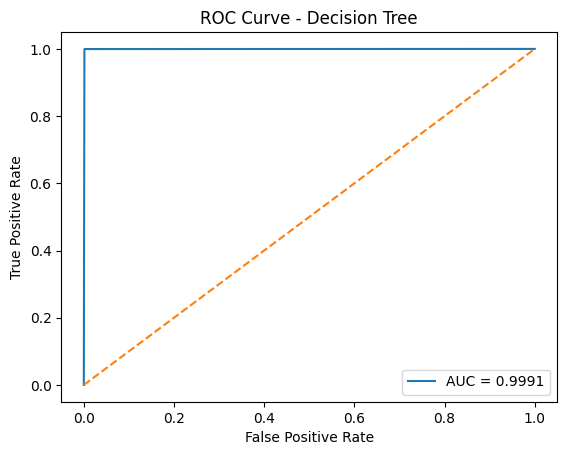

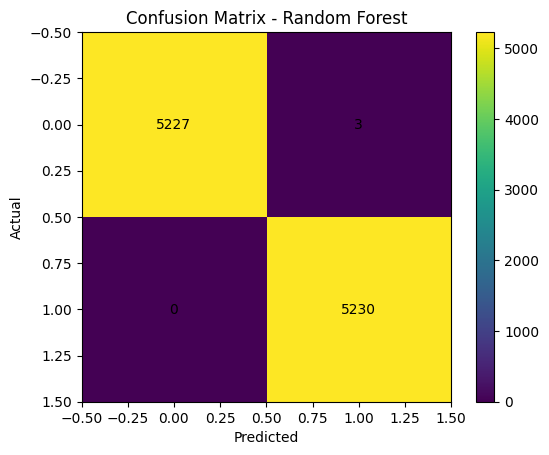

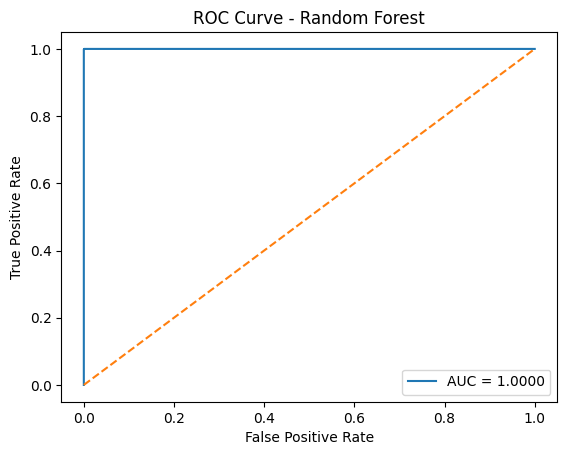

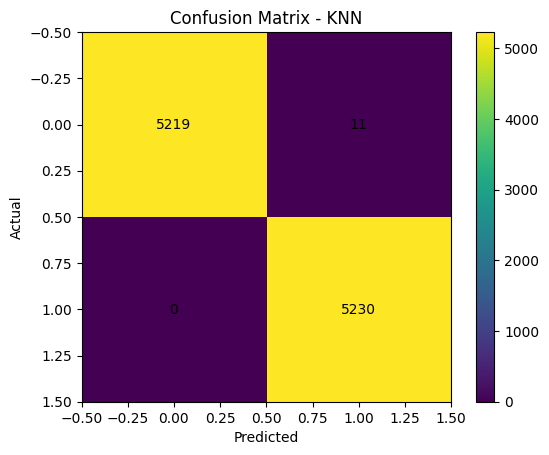

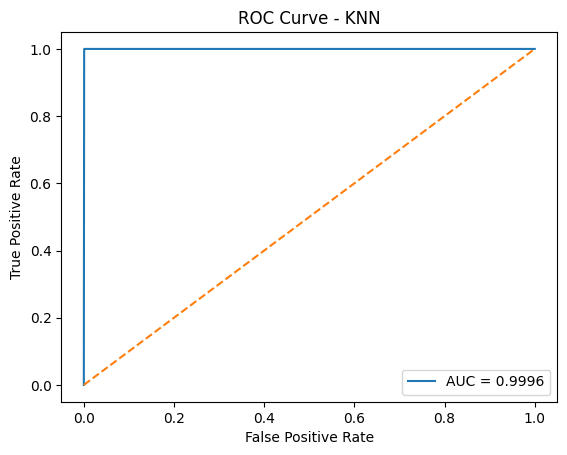

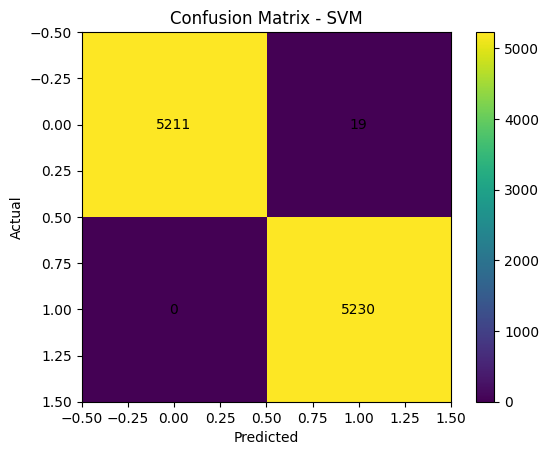

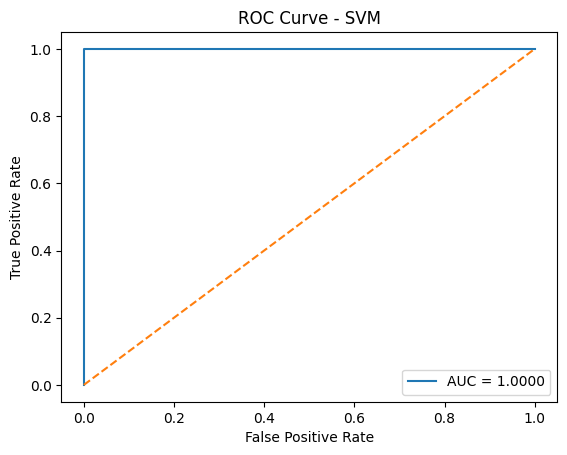

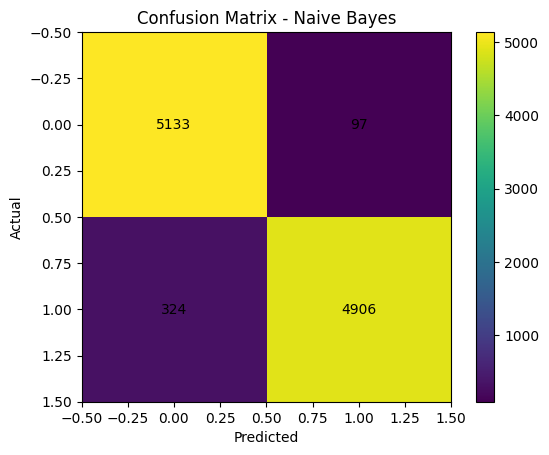

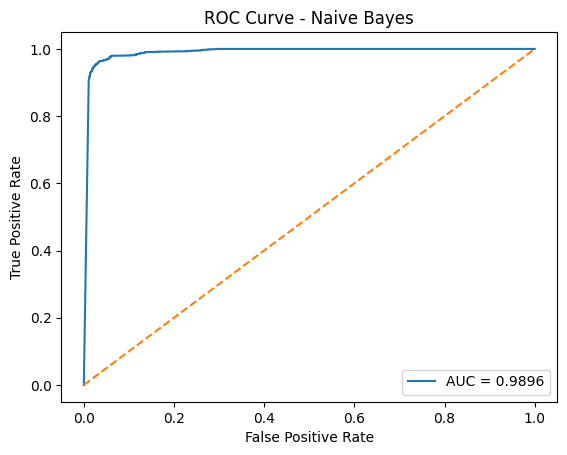

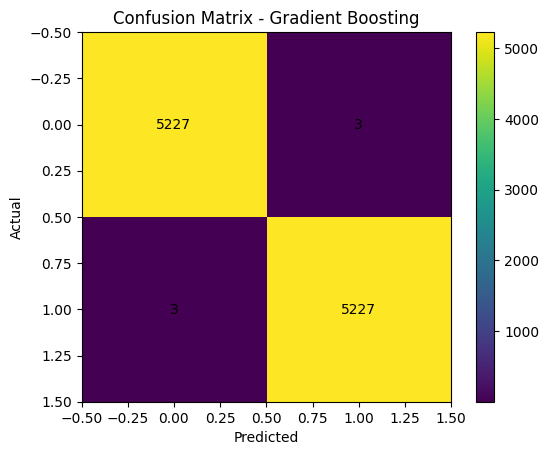

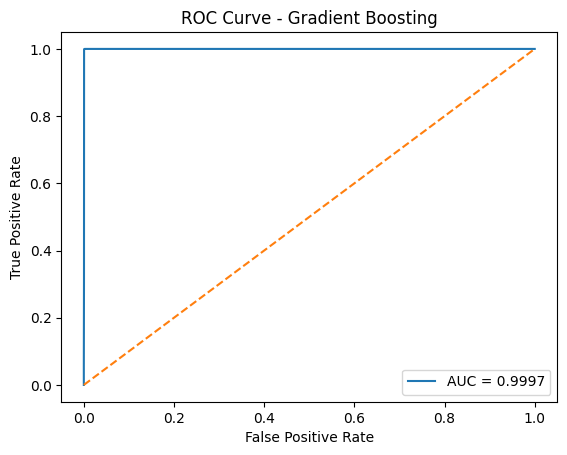

                     Accuracy  Precision    Recall  Specificity   ROC-AUC
Logistic Regression  0.989197   0.990792  0.987572     0.990822  0.998676
Decision Tree        0.999140   0.998663  0.999618     0.998662  0.999140
Random Forest        0.999713   0.999427  1.000000     0.999426  1.000000
KNN                  0.998948   0.997901  1.000000     0.997897  0.999618
SVM                  0.998184   0.996380  1.000000     0.996367  0.999980
Naive Bayes          0.959751   0.980612  0.938050     0.981453  0.989643
Gradient Boosting    0.999426   0.999426  0.999426     0.999426  0.999687


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Load dataset
data = pd.read_csv("/content/creditcard_smote.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    # Confusion Matrix
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {results[name]['ROC-AUC']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

# Results table
results_df = pd.DataFrame(results).T
print(results_df)

In [ ]:
pip install tensorflow


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, Dense, Flatten, Dropout,
    BatchNormalization, MaxPooling1D,
    Input, Add, Concatenate
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


## ***`ML CLASSIFIERS`***

Total rows: 454902
Total features (before scaling): 30
Training rows: 318431
Testing rows: 136471

Training Logistic Regression...


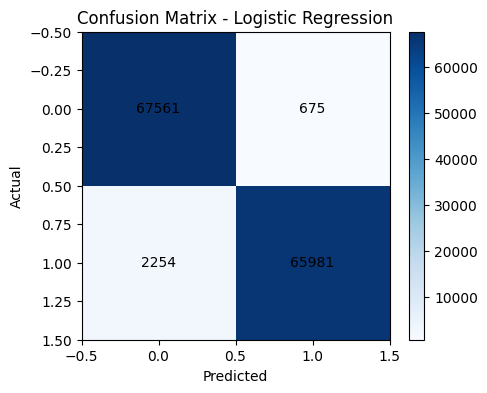

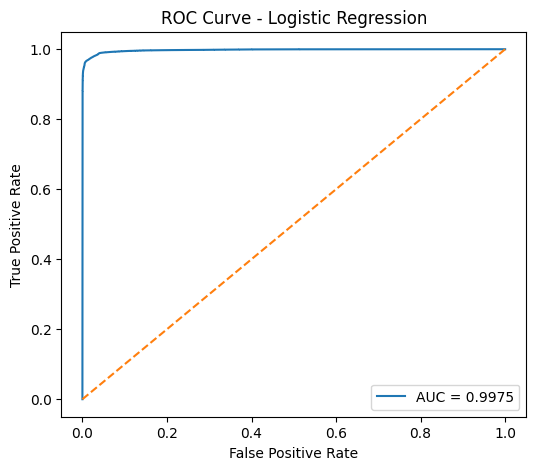

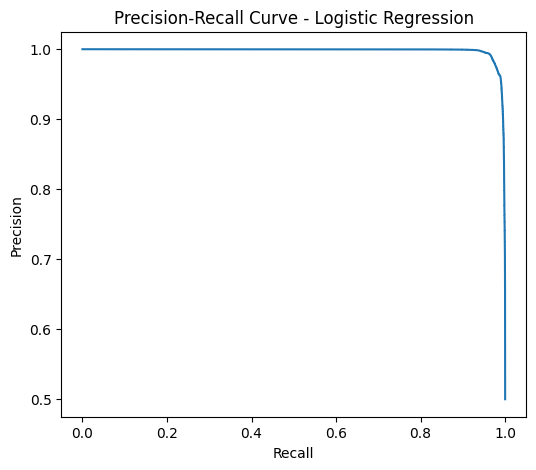


Training Decision Tree...


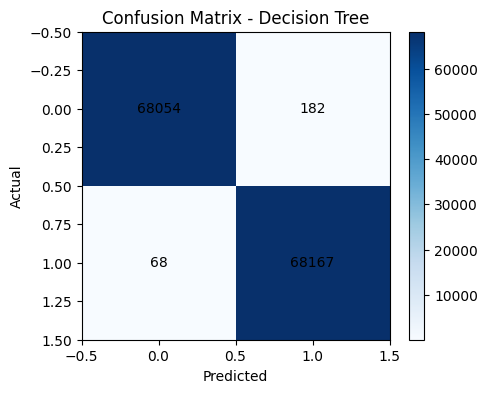

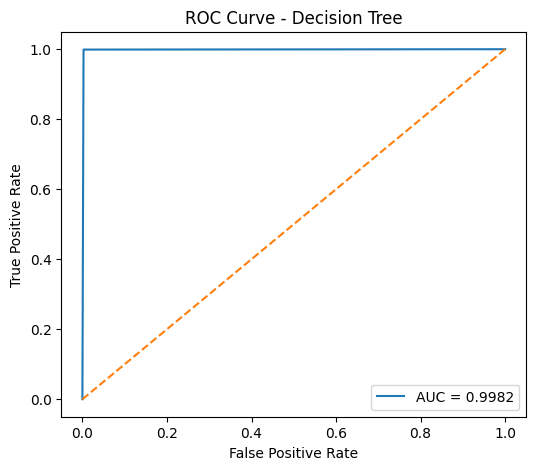

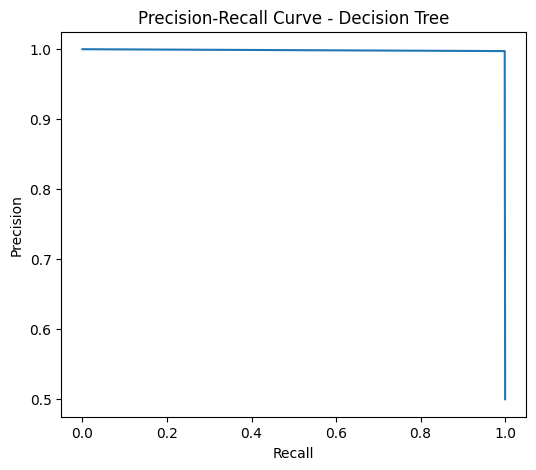


Training Random Forest...


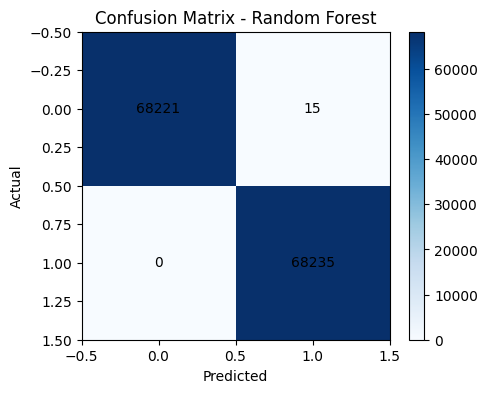

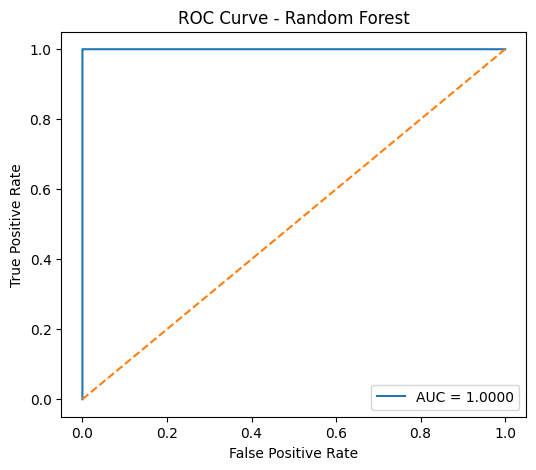

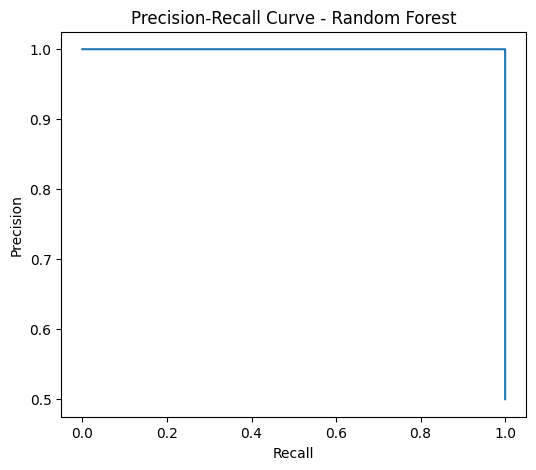


Training KNN...


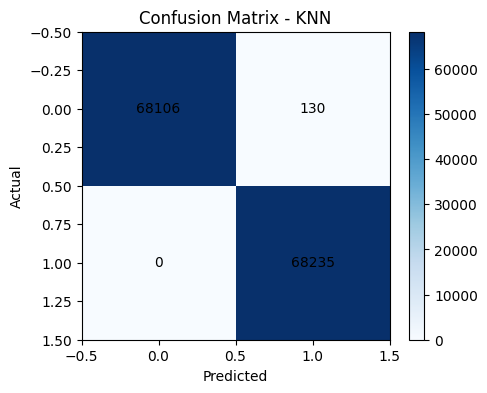

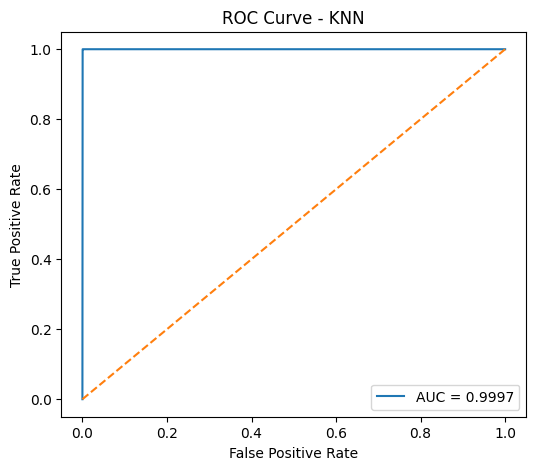

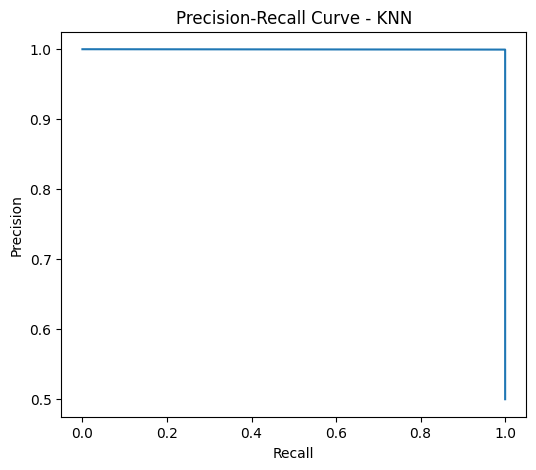


Training SVM...


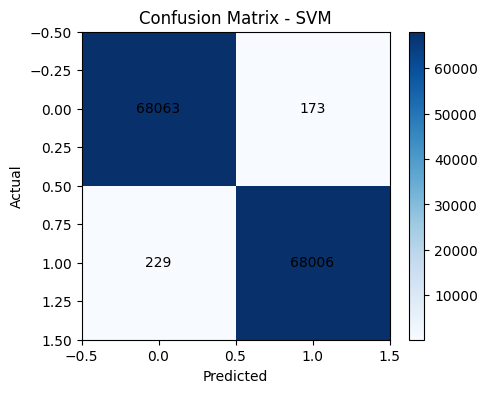

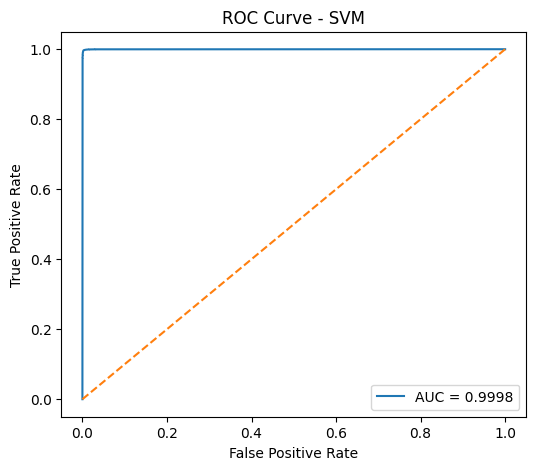

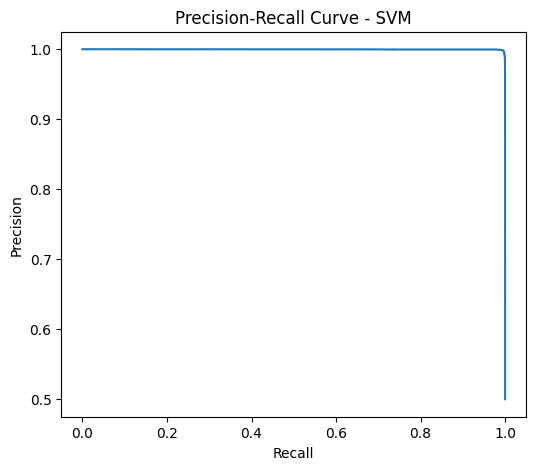


Training Naive Bayes...


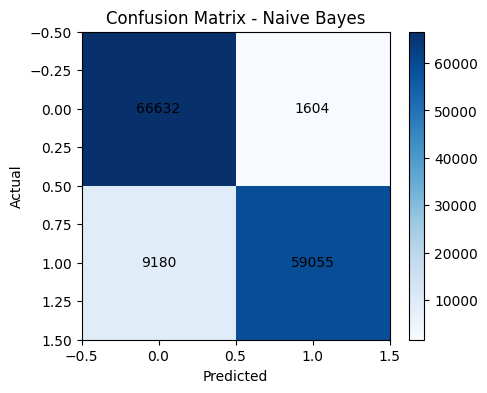

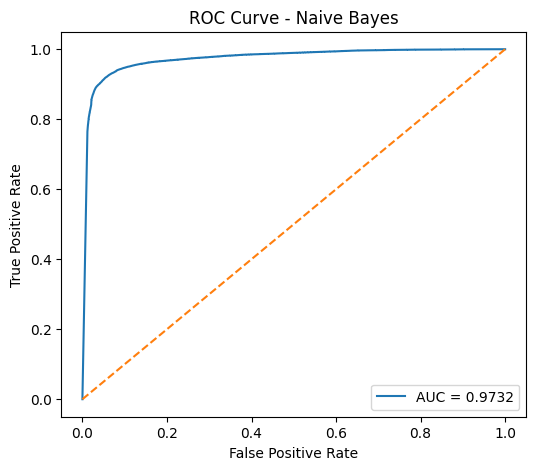

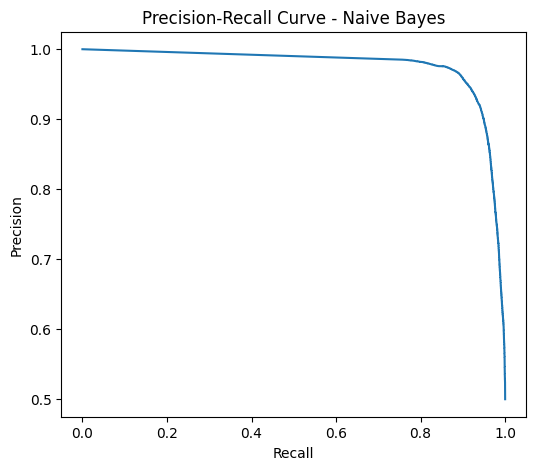


Training Gradient Boosting...


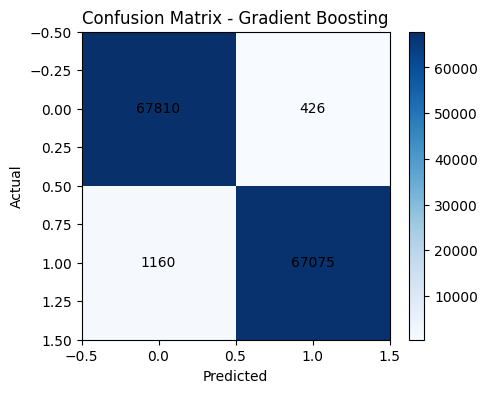

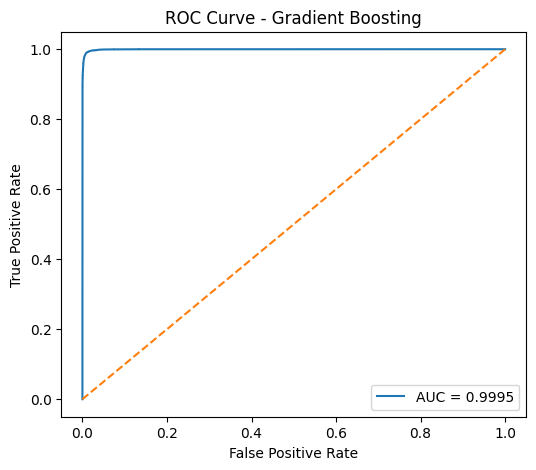

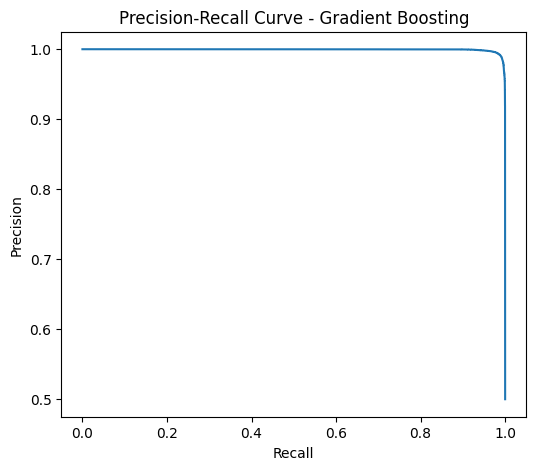


Training MLP Neural Network...


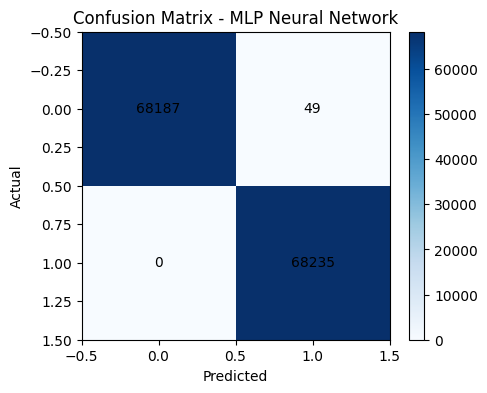

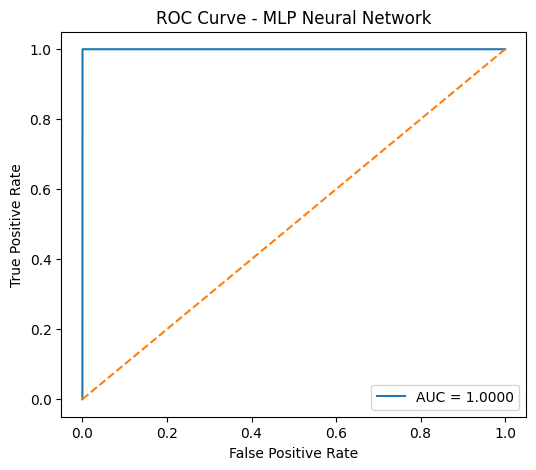

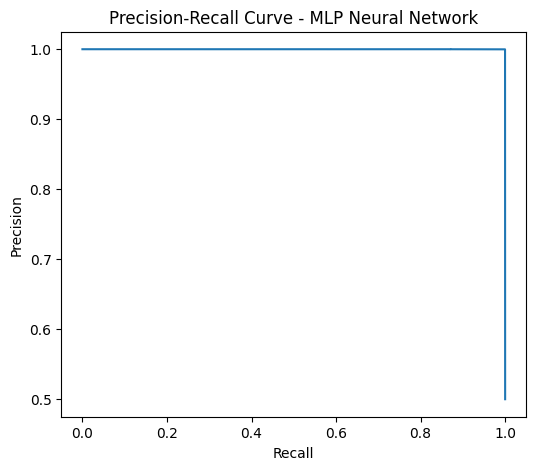


Training Ensemble KNN (Bagging)...


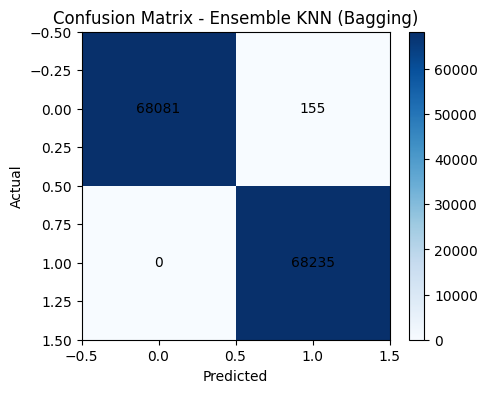

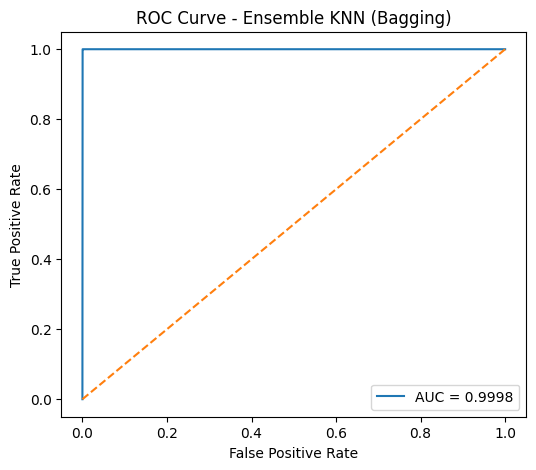

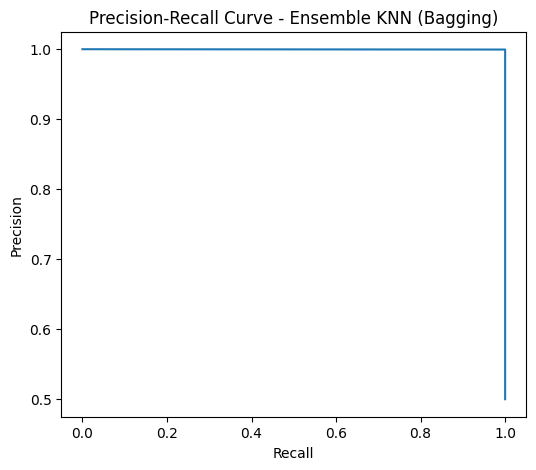


📊 Final Model Comparison:
                        Accuracy  Precision    Recall  F1 Score  Specificity  \
Random Forest           0.999890   0.999780  1.000000  0.999890     0.999780   
MLP Neural Network      0.999641   0.999282  1.000000  0.999641     0.999282   
KNN                     0.999047   0.998098  1.000000  0.999048     0.998095   
Ensemble KNN (Bagging)  0.998864   0.997734  1.000000  0.998866     0.997728   
Decision Tree           0.998168   0.997337  0.999003  0.998170     0.997333   
SVM                     0.997054   0.997463  0.996644  0.997053     0.997465   
Gradient Boosting       0.988378   0.993689  0.983000  0.988316     0.993757   
Logistic Regression     0.978538   0.989873  0.966967  0.978286     0.990108   
Naive Bayes             0.920980   0.973557  0.865465  0.916334     0.976493   

                         ROC-AUC  
Random Forest           0.999999  
MLP Neural Network      0.999994  
KNN                     0.999736  
Ensemble KNN (Bagging)  0.999766

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


# ==============================
# ✅ Load Dataset
# ==============================
data = pd.read_csv("/content/creditcard_smote.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Total rows:", data.shape[0])
print("Total features (before scaling):", X.shape[1])


# ==============================
# ✅ Feature Scaling
# ==============================
scaler = StandardScaler()
X = scaler.fit_transform(X)


# ==============================
# ✅ Train-Test Split (30% test)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,        # 🔹 30% for testing
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


# ==============================
# ✅ Models (Including Ensemble KNN)
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    ),

    "Ensemble KNN (Bagging)": BaggingClassifier(
        estimator=KNeighborsClassifier(n_neighbors=5),
        n_estimators=10,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
}


# ==============================
# ✅ Training & Evaluation
# ==============================
results = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Specificity": tn / (tn + fp),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    # ==============================
    # Confusion Matrix
    # ==============================
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

    # ==============================
    # ROC Curve
    # ==============================
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {results[name]['ROC-AUC']:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # ==============================
    # Precision–Recall Curve
    # ==============================
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.show()


# ==============================
# ✅ Final Results Table
# ==============================
results_df = pd.DataFrame(results).T
print("\n📊 Final Model Comparison:")
print(results_df.sort_values(by="F1 Score", ascending=False))


### ***1D CNN***

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Add, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping


## **LOAD THE DATASET**

In [ ]:
data = pd.read_csv("/content/creditcard_smote.csv")

X = data.iloc[:, :-1].values   # features
y = data.iloc[:, -1].values    # target


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

input_shape = X_train.shape[1:]


In [ ]:
def evaluate_model(model, X_test, y_test):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [ ]:
##vgg1D


def VGG1D(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(256, 3, activation='relu'),
        GlobalAveragePooling1D(),

        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    return model

##reSNET 1D
def res_block(x, filters):
    shortcut = x
    x = Conv1D(filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Add()([shortcut, x])
    return tf.keras.activations.relu(x)

def ResNet1D(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.activations.relu(x)

    x = res_block(x, 64)
    x = res_block(x, 64)

    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(1, activation='sigmoid')(x)

    return Model(inputs, x)

#GOOGLENET
def inception_block(x):
    b1 = Conv1D(32, 1, activation='relu', padding='same')(x)
    b2 = Conv1D(32, 3, activation='relu', padding='same')(x)
    b3 = Conv1D(32, 5, activation='relu', padding='same')(x)
    return Concatenate()([b1, b2, b3])

def Inception1D(input_shape):
    inputs = Input(shape=input_shape)
    x = inception_block(inputs)
    x = inception_block(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(1, activation='sigmoid')(x)
    return Model(inputs, x)

#DENSENET
def dense_block(x, filters):
    y = Conv1D(filters, 3, padding='same', activation='relu')(x)
    return Concatenate()([x, y])

def DenseNet1D(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, padding='same', activation='relu')(inputs)

    x = dense_block(x, 32)
    x = dense_block(x, 32)
    x = dense_block(x, 32)

    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(1, activation='sigmoid')(x)

    return Model(inputs, x)

#EFFICIENTNET
def EfficientNet1D(input_shape):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        BatchNormalization(),

        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),

        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

#TRAINING AND EVALUATION
models = {
    "VGG-1D": VGG1D(input_shape),
    "ResNet-1D": ResNet1D(input_shape),
    "Inception-1D": Inception1D(input_shape),
    "DenseNet-1D": DenseNet1D(input_shape),
    "EfficientNet-1D": EfficientNet1D(input_shape)
}

results = {}

for name, model in models.items():
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    results[name] = evaluate_model(model, X_test, y_test)
results_df = pd.DataFrame(results).T
print(results_df)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4265/4265 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
                 Accuracy  Precision    Recall        F1  Specificity  \
VGG-1D           0.999531   0.999195  0.999868  0.999531     0.999194   
ResNet-1D        0.999304   0.999326  0.999282  0.999304     0.999326   
Inception-1D     0.999700   0.999399  1.000000  0.999700     0.999399   
DenseNet-1D      0.999619   0.999282  0.999956  0.999619     0.999282   
EfficientNet-1D  0.998828   0.997690  0.999971  0.998829     0.997685   

                  ROC-AUC  
VGG-1D           0.999917  
ResNet-1D        0.999970  
Inception-1D     0.999967  
DenseNet-1D      0.999979  
EfficientNet-1D  0.999948  
